# Julio García Ortiz

Ejercicio para uso de K-Means para la segmentacion de imágenes

1. Importación de librerías

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

2. Carga y visualización de los datos

Dimensiones: 1920x1280 px
Total de píxeles: 2,457,600


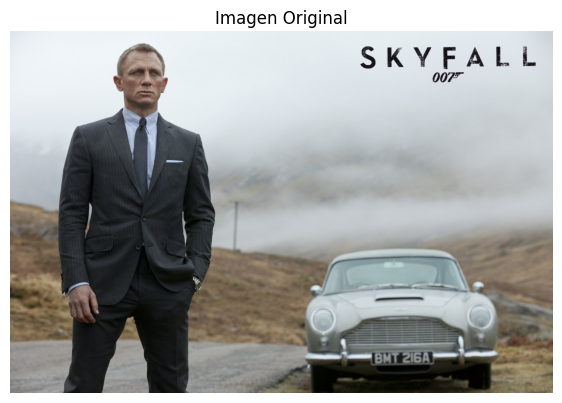

In [ ]:
# ruta de la imagen adjuntada (relativa), cambiar si el usuario sube foto propia
nombre_imagen = '007 Skyfall-Aston Martin DB-5.jpg'

# Cargamos la imagen
img = cv2.imread(nombre_imagen)

if img is None:
    raise FileNotFoundError(f'No se encontró la imagen: {nombre_imagen}')

# Convertir de BGR (OpenCV) a RGB (Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f'Dimensiones: {img_rgb.shape[1]}x{img_rgb.shape[0]} px')
print(f'Total de píxeles: {img_rgb.shape[0] * img_rgb.shape[1]:,}')

# Visualización de la imagen original
plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.show()

3. Aplicación de K-Means

In [ ]:
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# definimos el numero de K que es = al numero de clusters
k = 3

# Definimos criterios como el numero de iteraciones y la precision
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

# Aplicamos K-Means
compactness, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convertir centros a valores de 8 bits y reconstruir la imagen
centers = np.uint8(centers)
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(img_rgb.shape)

4. Mostrar resultados

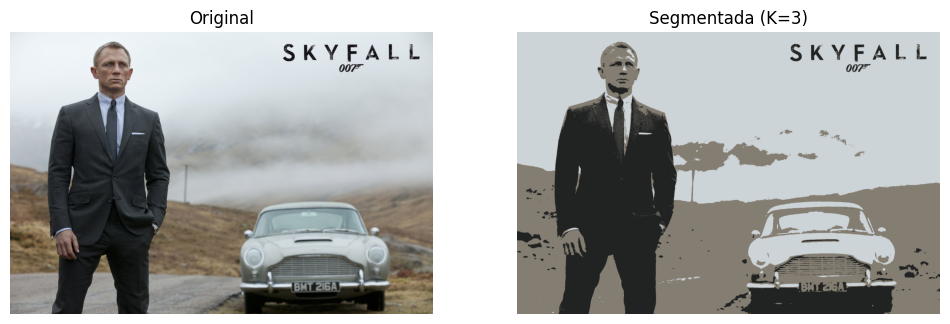

In [ ]:
# Comparativa de imagen original y la ya segmentada
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'Segmentada (K={k})')
plt.axis('off')

plt.show()